# Single layer neural network — two moons classification

This notebook builds a neural network with **one hidden layer** (2 input features → 4 hidden units with `tanh` → 1 output unit with `sigmoid`) completely from scratch using NumPy, and trains it to classify the classic *two moons* dataset — a dataset that isn't linearly separable, so it's a good test of whether the network is actually learning a non-linear decision boundary.

## 1. Load and explore the dataset

In [139]:
import numpy as np 
import pandas as pd
import copy
import matplotlib.pyplot as plt


In [140]:
df = pd.read_csv("two_moons.csv")
df.head()

,x1,x2,label
0,0.830858,-0.334342,1
1,0.991710,0.879000,0
2,1.107245,-0.470344,1
3,-0.140899,1.033148,0
4,0.405592,1.328529,0


In [141]:
df.describe()

,x1,x2,label
count,500.000000,500.000000,500.000000
mean,0.518145,0.255367,0.500000
std,0.895432,0.543603,0.500501
min,-1.476127,-0.988526,0.000000
25%,-0.086818,-0.195163,0.000000
50%,0.479565,0.280467,0.500000
75%,1.122974,0.685076,1.000000
max,2.484802,1.504279,1.000000


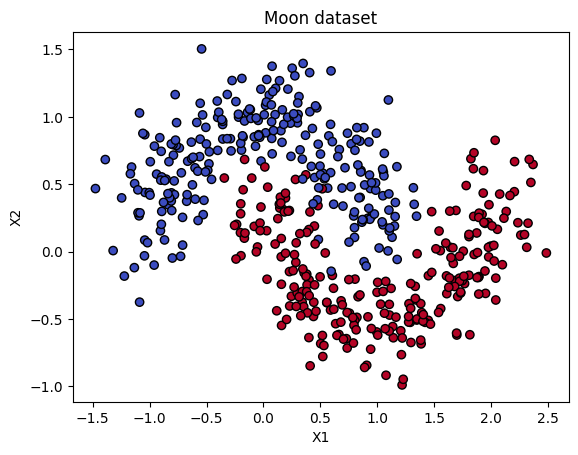

In [142]:
plt.scatter(
    x=df["x1"],
    y=df["x2"],
    c=df["label"],
    cmap="coolwarm",
    edgecolors="black"
    )
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Moon dataset")
plt.show()

## 2. Prepare the data for training

In [143]:
X = df.drop("label",axis=1)
Y = df["label"]



In [144]:
X.shape

(500, 2)

In [145]:
X.head()

,x1,x2
0,0.830858,-0.334342
1,0.991710,0.879000
2,1.107245,-0.470344
3,-0.140899,1.033148
4,0.405592,1.328529


In [146]:
Y.shape

(500,)

In [147]:
Y.head()

0    1
1    0
2    1
3    0
4    0
Name: label, dtype: int64

In [148]:
X = X.to_numpy()
Y = Y.to_numpy()


In [149]:
Y = Y.reshape(-1,1)
print(Y.shape)

(500, 1)


## 3. Define the network architecture

- **Input layer**: `n_x` = number of features (2)
- **Hidden layer**: `n_h` = 4 units
- **Output layer**: `n_y` = 1 unit (binary classification)

In [150]:
def layer_size(X,Y):
    n_x = X.shape[1]
    n_h = 4
    n_y = 1
    return n_x,n_h,n_y

In [151]:
n_x,n_h,n_y = layer_size(X,Y)

## 4. Initialize parameters

In [152]:
def initialize_parameters(n_x,n_h,n_y):
    np.random.seed(42)
    W1 = np.random.randn(n_x,n_h)*0.01
    b1 = np.zeros((1,n_h))
    W2 = np.random.randn(n_h,n_y)*0.01
    b2 = np.zeros((1,n_y))
    
    paramters = {
        "W1" : W1,
        "b1" : b1,
        "W2" : W2,
        "b2" : b2
    }
    return paramters

In [153]:
parameters = initialize_parameters(n_x,n_h,n_y)
print("W1 : ",parameters["W1"])
print("b1 : ",parameters["b1"])
print("W2 : ",parameters["W2"])
print("b2 : ",parameters["b2"])


W1 :  [[ 0.00496714 -0.00138264  0.00647689  0.0152303 ]
 [-0.00234153 -0.00234137  0.01579213  0.00767435]]
b1 :  [[0. 0. 0. 0.]]
W2 :  [[-0.00469474]
 [ 0.0054256 ]
 [-0.00463418]
 [-0.0046573 ]]
b2 :  [[0.]]


In [154]:
print("W1 : ", parameters["W1"].shape)
print("W2 : ", parameters["W2"].shape)
print("b1 : ", parameters["b1"].shape)
print("b2 : ", parameters["b2"].shape)

W1 :  (2, 4)
W2 :  (4, 1)
b1 :  (1, 4)
b2 :  (1, 1)


## 5. Forward propagation

In [155]:
def sigmoid(A):
    return 1/(1+np.exp(-(A)))

In [156]:
def forward_propagation(X,parametes):
    W1 = parametes["W1"]
    b1 = parametes["b1"]
    W2 = parametes["W2"]
    b2 = parametes["b2"]
    
    Z1 = np.dot(X,W1)+b1
    A1 = np.tanh(Z1)
    Z2 = np.dot(A1,W2) + b2
    A2 = sigmoid(Z2)
    cache = {
        "Z1" : Z1,
        "Z2" : Z2,
        "A1" : A1,
        "A2" : A2
    }
    return cache,A2

In [157]:
cache,A2 = forward_propagation(X,parameters)

In [158]:
print("Z1 : ",cache["Z1"].shape)
print("Z2 : ",cache["Z2"].shape)
print("A1 : ",cache["A1"].shape)
print("A2 : ",cache["A2"].shape)


Z1 :  (500, 4)
Z2 :  (500, 1)
A1 :  (500, 4)
A2 :  (500, 1)


## 6. Cost function

In [159]:
def find_cost(A2,Y):
    m = Y.shape[0]
    inner_val = np.multiply(np.log(A2),Y)+ np.multiply(np.log(1-A2),(1-Y))
    cost = -(1/m) * np.sum(inner_val)
    cost = float(np.squeeze(cost))
    return cost


In [160]:
cost = find_cost(A2,Y)
print(cost)

0.6931589599303377


## 7. Backward propagation

In [161]:
def back_propagation(parameters,cache,X,Y):
    m = X.shape[0]
    W1 = parameters["W1"]
    W2 = parameters["W2"]
    A1 = cache["A1"]
    A2 = cache["A2"]
    
    dZ2 = A2 - Y
    dW2 = (1/m) * np.dot(A1.T,dZ2)
    db2 = (1/m) * np.sum(dZ2,axis = 0, keepdims = True)
    
    dZ1 = np.dot(dZ2,W2.T) * (1 - np.power(A1, 2))
    dW1 = (1/m) * np.dot(X.T,dZ1)
    db1 = (1/m)*np.sum(dZ1,axis=0,keepdims=True)
    
    grads = {
        "dZ1" : dZ1,
        "dZ2" : dZ2,
        "dW1" : dW1,
        "dW2" : dW2,
        "db1" : db1,
        "db2" : db2
    }
    return grads
    

In [162]:
grads = back_propagation(parameters,cache,X,Y)
print("dZ1 : ",grads["dZ1"].shape)
print("dZ2 : ",grads["dZ2"].shape)
print("dW1 : ",grads["dW1"].shape)
print("dW2 : ",grads["dW2"].shape)
print("db1 : ",grads["db1"].shape)
print("db2 : ",grads["db2"].shape)

dZ1 :  (500, 4)
dZ2 :  (500, 1)
dW1 :  (2, 4)
dW2 :  (4, 1)
db1 :  (1, 4)
db2 :  (1, 1)


## 8. Update parameters (gradient descent step)

In [163]:
def update_params(parameters,grads,learning_rate):
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    dW1 = grads["dW1"]
    dW2 = grads["dW2"]
    db1 = grads["db1"]
    db2 = grads["db2"]
    
    W1 = W1 - learning_rate * dW1
    W2 = W2 - learning_rate * dW2
    b1 = b1 - learning_rate * db1
    b2 = b2 - learning_rate * db2
    
    parameters = {
        "W1" : W1,
        "W2" : W2,
        "b1" : b1,
        "b2" : b2
    }
    return parameters

In [164]:
parameters = update_params(parameters,grads,learning_rate=0.05)
print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))

W1 = [[ 0.00490734 -0.00131353  0.00641786  0.01517101]
 [-0.00229531 -0.00239479  0.01583775  0.0077202 ]]
b1 = [[-4.07276716e-09  6.60532280e-09 -1.00338930e-08  5.74470442e-09]]
W2 = [[-0.00460842]
 [ 0.00543104]
 [-0.00470715]
 [-0.00453888]]
b2 = [[1.20644507e-06]]


## 9. Train the model

Ties everything together: initialize → forward prop → cost → backprop → update, repeated for a number of iterations.

In [215]:
def single_layer_nn(X,Y,n_h,iterations):
    np.random.seed(42)
    n_x = layer_size(X,Y)[0]
    n_y =  layer_size(X,Y)[2]
    alpha = 1.5
    parameters = initialize_parameters(n_x,n_h,n_y)
    for i in range(0,iterations):
        cache,A2 = forward_propagation(X,parameters)
        cost = find_cost(A2,Y)
        grads = back_propagation(parameters,cache,X,Y)
        parameters = update_params(parameters,grads,learning_rate=alpha)
        if i % 100 == 0:
            print ("Cost after iteration %i: %f" %(i, cost))
    return parameters
        
        

In [216]:
parameters = single_layer_nn(X,Y,n_h,1500)


Cost after iteration 0: 0.693159
Cost after iteration 100: 0.286136
Cost after iteration 200: 0.284022
Cost after iteration 300: 0.283459
Cost after iteration 400: 0.281521
Cost after iteration 500: 0.278144
Cost after iteration 600: 0.152650
Cost after iteration 700: 0.076410
Cost after iteration 800: 0.064183
Cost after iteration 900: 0.059495
Cost after iteration 1000: 0.056947
Cost after iteration 1100: 0.055302
Cost after iteration 1200: 0.054128
Cost after iteration 1300: 0.053232
Cost after iteration 1400: 0.052513


## 10. Make predictions

In [217]:
def predict(X,parameters):
    cache,A2 = forward_propagation(X,parameters)
    prediction = (A2>0.5).astype(int)
    return prediction

In [218]:
predictions = predict(X,parameters)
print(predictions)

[[1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]


## 11. Visualize the decision boundary

In [219]:
def plot_decision_boundary(pred_func, X, Y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.01

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    # Use the prediction function
    Z = pred_func(grid)

    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=Y.ravel(),
                cmap=plt.cm.Spectral, edgecolors='k')

Cost after iteration 0: 0.693159
Cost after iteration 100: 0.286136
Cost after iteration 200: 0.284022
Cost after iteration 300: 0.283459
Cost after iteration 400: 0.281521
Cost after iteration 500: 0.278144
Cost after iteration 600: 0.152650
Cost after iteration 700: 0.076410
Cost after iteration 800: 0.064183
Cost after iteration 900: 0.059495
Cost after iteration 1000: 0.056947
Cost after iteration 1100: 0.055302
Cost after iteration 1200: 0.054128
Cost after iteration 1300: 0.053232
Cost after iteration 1400: 0.052513
Cost after iteration 1500: 0.051914
Cost after iteration 1600: 0.051394
Cost after iteration 1700: 0.050928
Cost after iteration 1800: 0.050493
Cost after iteration 1900: 0.050068
Cost after iteration 2000: 0.049631
Cost after iteration 2100: 0.049156
Cost after iteration 2200: 0.048624
Cost after iteration 2300: 0.048023
Cost after iteration 2400: 0.047355
Cost after iteration 2500: 0.046629
Cost after iteration 2600: 0.045869
Cost after iteration 2700: 0.045101
Cost

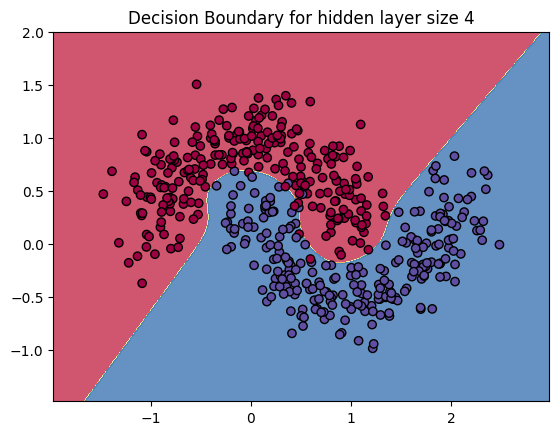

In [220]:
parameters = single_layer_nn(X, Y, n_h=4, iterations=10000)

plot_decision_boundary(lambda x: predict(x,parameters), X, Y)
plt.title("Decision Boundary for hidden layer size 4")
plt.show()